In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import seaborn as sns
import warnings
from matplotlib import pyplot as plt
from pymc_marketing.mmm.multidimensional import MMM
from pymc_extras.prior import Prior
from pymc_marketing.special_priors import LogNormalPrior, LaplacePrior
from pymc_marketing.mmm import LogisticSaturation, GeometricAdstock

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = '{:,.5f}'.format

/Users/ME/CODING/mmm/.venv/lib/python3.13/site-packages/pymc_marketing/pytensor_utils.py:34: FutureWarning: `pytensor.graph.basic.ancestors` was moved to `pytensor.graph.traversal.ancestors`. Calling it from the old location will fail in a future release.
  from pytensor.graph.basic import ancestors
/Users/ME/CODING/mmm/.venv/lib/python3.13/site-packages/pymc_marketing/mmm/multidimensional.py:216: FutureWarning: This functionality is experimental and subject to change. If you encounter any issues or have suggestions, please raise them at: https://github.com/pymc-labs/pymc-marketing/issues/new
  warnings.warn(warning_msg, FutureWarning, stacklevel=1)


In [3]:
seed = 1312
rng = np.random.default_rng(seed)

filename = 'data/ex.csv'
try:
    df = pd.read_csv(filename, parse_dates=['date'])
except FileNotFoundError:
    print(f'Could not locate data file with filename {filename}. Check file path')
print(f'The shape of the dataset is: {df.shape}')
display(df.head())
print(df.info())

The shape of the dataset is: (318, 7)


,date,geo,x1,x2,event_1,event_2,y
0,2022-06-06,geo_a,"5,527.64008",0.00000,0,0,"2,647.59636"
1,2022-06-06,geo_b,"8,849.25750","8,063.91839",0,0,682.40628
2,2022-06-13,geo_a,"6,692.65569",0.00000,0,0,"5,020.82391"
3,2022-06-13,geo_b,"9,073.81799","9,354.01458",0,0,"3,753.10490"
4,2022-06-20,geo_a,"7,124.01673",0.00000,0,0,"6,184.32213"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318 entries, 0 to 317
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     318 non-null    datetime64[ns]
 1   geo      318 non-null    object        
 2   x1       318 non-null    float64       
 3   x2       318 non-null    float64       
 4   event_1  318 non-null    int64         
 5   event_2  318 non-null    int64         
 6   y        318 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 17.5+ KB
None


In [4]:
x_train = df.drop(columns=['y'])
y_train = df['y']

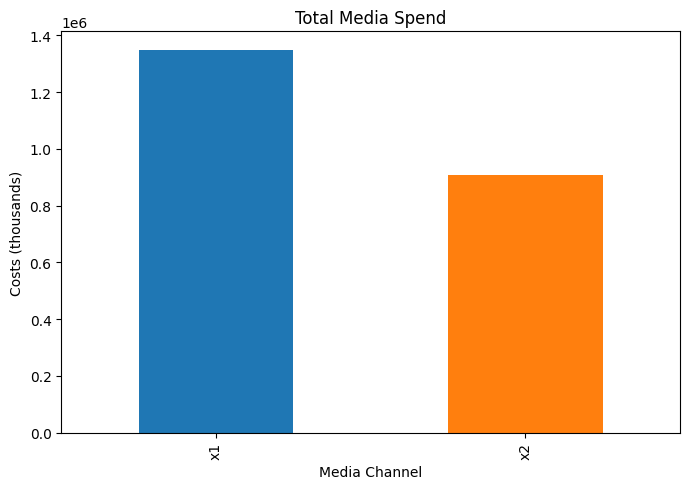

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
df[["x1", "x2"]].sum().plot(kind="bar", color=["C0", "C1"], ax=ax)
ax.set(title="Total Media Spend", xlabel="Media Channel", ylabel="Costs (thousands)")
plt.tight_layout()

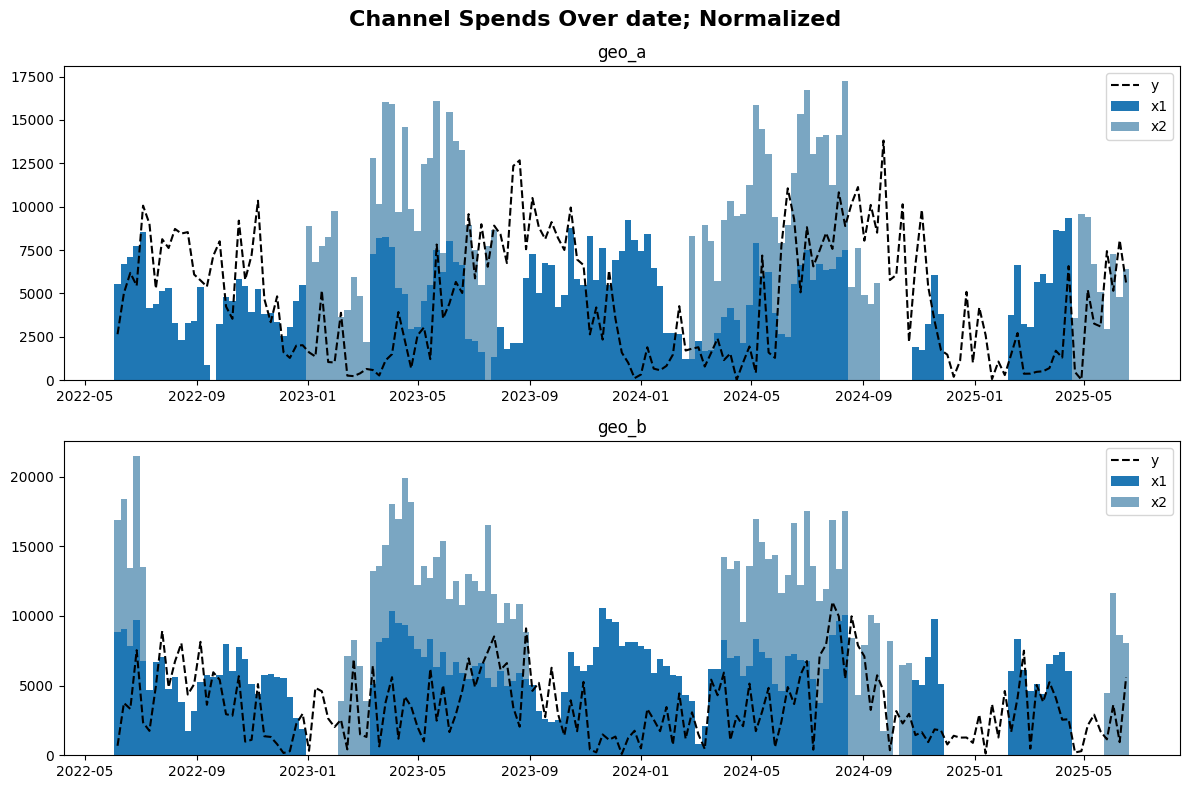

In [8]:


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("Channel Spends Over date; Normalized", fontsize=16, fontweight="bold")

blue_colors = ["#1f77b4", "#7aa6c2"]

# Plot for geo_0
geo_0_data = df[df["geo"] == "geo_a"]
ax1.bar(geo_0_data["date"], geo_0_data["x1"], label="x1", width=7, color=blue_colors[0])
ax1.bar(
    geo_0_data["date"],
    geo_0_data["x2"],
    bottom=geo_0_data["x1"],
    label="x2",
    width=7,
    color=blue_colors[1],
)
ax1.plot(geo_0_data["date"], geo_0_data["y"], "--", label="y", color="black")
ax1.set_title("geo_a")
ax1.legend()

# Plot for geo_1
geo_1_data = df[df["geo"] == "geo_b"]
ax2.bar(geo_1_data["date"], geo_1_data["x1"], label="x1", width=7, color=blue_colors[0])
ax2.bar(
    geo_1_data["date"],
    geo_1_data["x2"],
    bottom=geo_1_data["x1"],
    label="x2",
    width=7,
    color=blue_colors[1],
)
ax2.plot(geo_1_data["date"], geo_1_data["y"], "--", label="y", color="black")
ax2.set_title("geo_b")
ax2.legend()

plt.tight_layout()

In [9]:
# Saturation curve transformation
# Note the hierarchical architecture: the hyperparams are each their own RV

beta_prior = LogNormalPrior(
    mean=Prior("Gamma", mu=0.25, sigma=0.10, dims="channel"),
    std=Prior("Exponential", scale=0.10, dims="channel"),
    dims=("channel", "geo"),
    centered=False,
)

lam_prior = Prior("Gamma", mu=0.5, sigma=0.25, dims="channel")

saturation = LogisticSaturation(
    priors={
        "beta": beta_prior,
        "lam": lam_prior,
    },
)

saturation.model_config

{'saturation_lam': Prior("Gamma", mu=0.5, sigma=0.25, dims="channel"),
 'saturation_beta': <pymc_marketing.special_priors.LogNormalPrior at 0x1233c9be0>}

In [10]:
# Adstock transformation

alpha_prior = Prior("Beta", alpha=2, beta=5, dims=("geo", "channel"))

adstock = GeometricAdstock(
    priors={"alpha": alpha_prior},
    l_max=8,  # 8 week decay
)

adstock.model_config

{'adstock_alpha': Prior("Beta", alpha=2, beta=5, dims=("geo", "channel"))}

In [11]:
model_config = {
    "intercept": Prior("Gamma", mu=0.5, sigma=0.25, dims="geo"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),
    "gamma_fourier": LaplacePrior(  # fourier for seasonality
        mu=0,
        b=Prior("HalfNormal", sigma=0.2),
        dims=("geo", "fourier_mode"),
        centered=False,
    ),
    "likelihood": Prior(
        "TruncatedNormal",
        lower=0,
        sigma=Prior("HalfNormal", sigma=5),  # original value = 1.5, 1 divergence at fitting
        dims=("date", "geo"),
    )
}

In [16]:
mmm = MMM(
    date_column="date",
    target_column="y",
    channel_columns=["x1", "x2"],
    control_columns=["event_1", "event_2"],
    dims=("geo",),
    scaling={
        "channel": {"method": "max", "dims": ()},
        "target": {"method": "max", "dims": ()},
    },
    adstock=adstock,
    saturation=saturation,
    yearly_seasonality=3,  # stable values = 1 - 10
    model_config=model_config
)

mmm.default_model_config

{'intercept': Prior("Normal", mu=0, sigma=2, dims="geo"),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims="geo"), dims="geo"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims=("geo", "control")),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims=("geo", "fourier_mode")),
 'adstock_alpha': Prior("Beta", alpha=2, beta=5, dims=("geo", "channel")),
 'saturation_lam': Prior("Gamma", mu=0.5, sigma=0.25, dims="channel"),
 'saturation_beta': <pymc_marketing.special_priors.LogNormalPrior at 0x1233c9be0>}

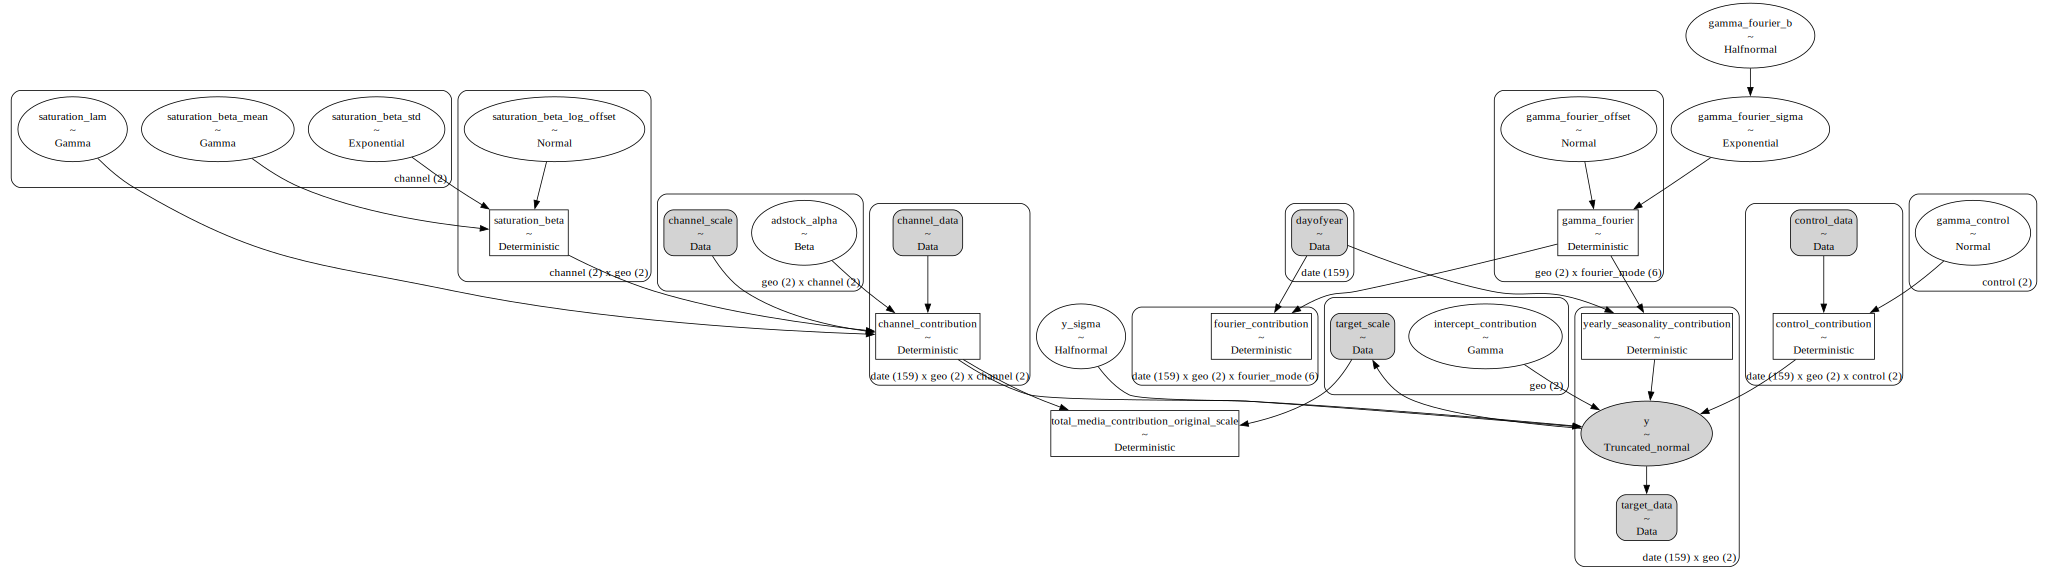

In [18]:
mmm.build_model(X=x_train, y=df["y"])
mmm.model.to_graphviz()

In [19]:
mmm.table()

                             Variable  Expression                             Dimensions                           
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                      channel_scale =  Data                                   geo[2] × channel[2]                  
                       target_scale =  Data                                   geo[2]                               
                       channel_data =  Data                                   date[159] × geo[2] × channel[2]      
                        target_data =  Data                                   date[159] × geo[2]                   
                       control_data =  Data                                   date[159] × geo[2] × control[2]      
                          dayofyear =  Data                                   date[159]                            
                                                                                                                   
             intercept_contribution ~  Gamma(f(), f())                        geo[2]                               
                      adstock_alpha ~  Beta(2, 5)                             geo[2] × channel[2]                  
                     saturation_lam ~  Gamma(f(), f())                        channel[2]                           
               saturation_beta_mean ~  Gamma(f(), f())                        channel[2]                           
                saturation_beta_std ~  Exponential(0.1)                       channel[2]                           
         saturation_beta_log_offset ~  Normal(0, 1)                           channel[2] × geo[2]                  
                      gamma_control ~  Normal(0, 0.5)                         control[2]                           
                    gamma_fourier_b ~  HalfNormal(0, 0.2)                                                          
                gamma_fourier_sigma ~  Exponential(f(gamma_fourier_b))                                             
               gamma_fourier_offset ~  Normal(0, 1)                           geo[2] × fourier_mode[6]             
                            y_sigma ~  HalfNormal(0, 5)                                                            
                                                                              Parameter count = 33                 
                                                                                                                   
                    saturation_beta =  f(saturation_beta_log_offset,          channel[2] × geo[2]                  
                                       saturation_beta_mean,                                                       
                                       saturation_beta_std)                                                        
               channel_contribution =  f(saturation_lam,                      date[159] × geo[2] × channel[2]      
                                       saturation_beta_log_offset,                                                 
                                       saturation_beta_mean, adstock_alpha,                                        
                                       saturation_beta_std)                                                        
 total_media_contribution_original_s…  f(saturation_lam,                                                           
                                    =  saturation_beta_log_offset,                                                 
                                       saturation_beta_mean, adstock_alpha,                                        
                                       saturation_beta_std)                                                        
               control_contribution =  f(gamma_control)                       date[159] × geo[2] × control[2]      
                      gamma_fourier =  f(gamma_fourier_o

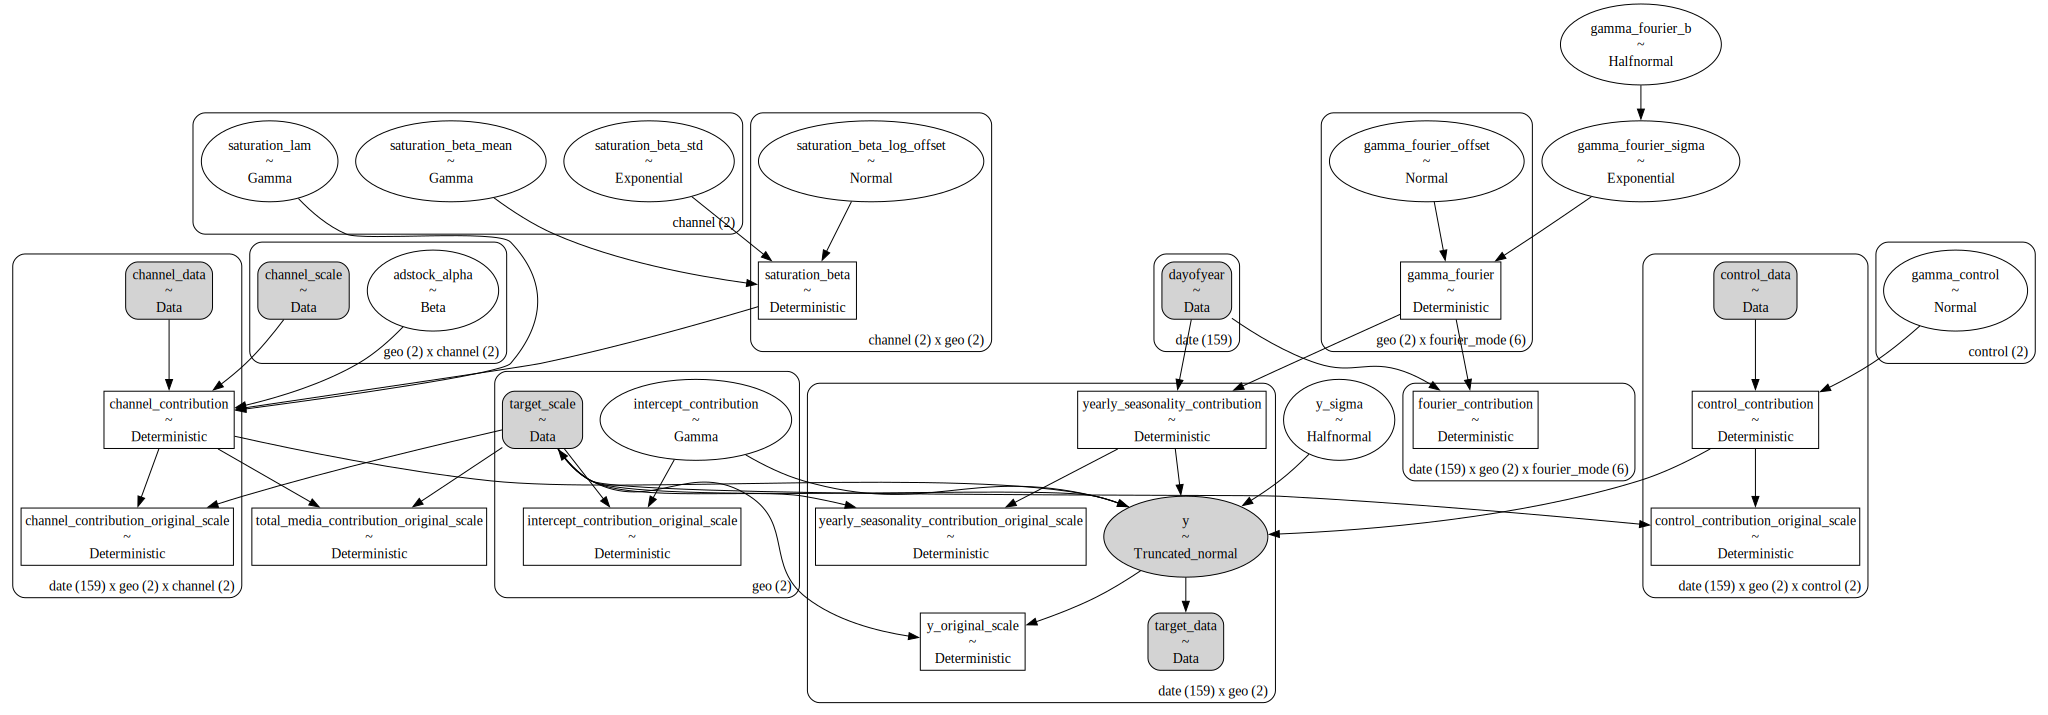

In [20]:
mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)

pm.model_to_graphviz(mmm.model)

In [21]:
scalers = mmm.get_scales_as_xarray()

scalers

{'channel_scale': <xarray.DataArray '_channel' (geo: 2, channel: 2)> Size: 32B
 array([[ 9318.97848455,  9755.9729876 ],
        [10555.0774866 , 11760.98180037]])
 Coordinates:
   * geo      (geo) object 16B 'geo_a' 'geo_b'
   * channel  (channel) object 16B 'x1' 'x2',
 'target_scale': <xarray.DataArray '_target' (geo: 2)> Size: 16B
 array([13812.08025674, 11002.97913936])
 Coordinates:
   * geo      (geo) object 16B 'geo_a' 'geo_b'}

In [22]:
with mmm.model:
    prior = pm.sample_prior_predictive()
prior

Sampling: [adstock_alpha, gamma_control, gamma_fourier_b, gamma_fourier_offset, gamma_fourier_sigma, intercept_contribution, saturation_beta_log_offset, saturation_beta_mean, saturation_beta_std, saturation_lam, y, y_sigma]


Inference data with groups:
	> prior
	> prior_predictive
	> observed_data
	> constant_data

Text(0.5, 1.03, 'Prior Predictive')

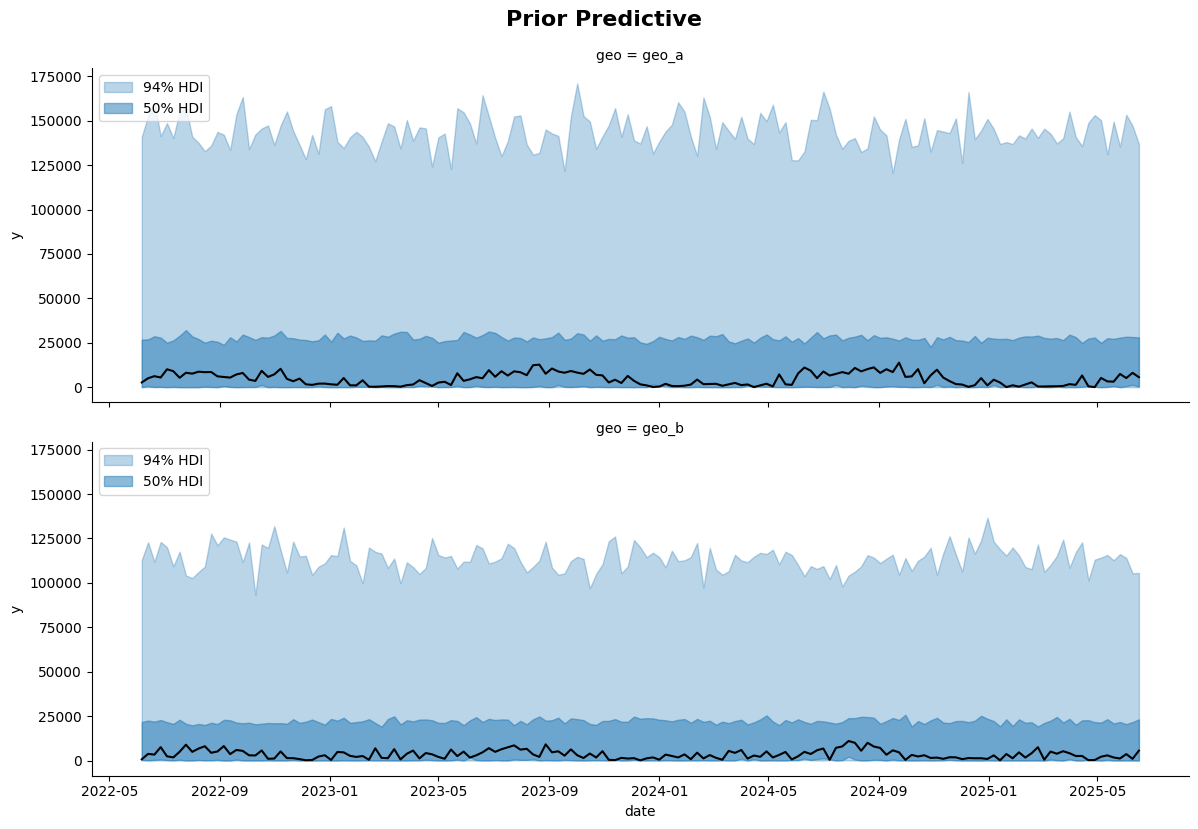

In [23]:

g = sns.relplot(
    data=df,
    x="date",
    y="y",
    color="black",
    col="geo",
    col_wrap=1,
    kind="line",
    height=4,
    aspect=3,
)

axes = g.axes.flatten()

for ax, geo in zip(axes, mmm.model.coords["geo"], strict=True):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=(
            prior.prior.sel(geo=geo)["y_original_scale"]
            .unstack()
            .transpose(..., "date")
        ),
        smooth=False,
        color="C0",
        hdi_prob=0.94,
        fill_kwargs={"alpha": 0.3, "label": "94% HDI"},
        ax=ax,
    )
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=(
            prior.prior.sel(geo=geo)["y_original_scale"]
            .unstack()
            .transpose(..., "date")
        ),
        smooth=False,
        color="C0",
        hdi_prob=0.5,
        fill_kwargs={"alpha": 0.5, "label": "50% HDI"},
        ax=ax,
    )
    ax.legend(loc="upper left")

g.figure.suptitle("Prior Predictive", fontsize=16, fontweight="bold", y=1.03)

In [24]:
mmm.fit(
    X=x_train,
    y=df["y"],
    chains=4,
    target_accept=0.95,
    random_seed=rng,
)

mmm.sample_posterior_predictive(
    X=x_train,
    random_seed=rng,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta_mean, saturation_beta_std, saturation_beta_log_offset, gamma_control, gamma_fourier_b, gamma_fourier_sigma, gamma_fourier_offset, y_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.


Output()

Sampling: [y]


Output()

<xarray.Dataset> Size: 20MB
Dimensions:           (date: 159, geo: 2, sample: 4000)
Coordinates:
  * date              (date) datetime64[ns] 1kB 2022-06-06 ... 2025-06-16
  * geo               (geo) <U5 40B 'geo_a' 'geo_b'
  * sample            (sample) object 32kB MultiIndex
  * chain             (sample) int64 32kB 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3
  * draw              (sample) int64 32kB 0 1 2 3 4 5 ... 995 996 997 998 999
Data variables:
    y                 (date, geo, sample) float64 10MB 0.1185 0.8035 ... 0.4277
    y_original_scale  (date, geo, sample) float64 10MB 1.637e+03 ... 4.705e+03
Attributes:
    created_at:                 2026-04-14T23:23:31.344680+00:00
    arviz_version:              0.23.0
    inference_library:          pymc
    inference_library_version:  5.27.0

In [25]:
az.summary(
    mmm.idata,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_beta_mean",
        "saturation_beta_std",
        "saturation_lam",
        "y_sigma",
    ],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"adstock_alpha[geo_a, x1]",0.30100,0.16700,0.01400,0.58900,0.00200,0.00300,"8,454.00000","2,767.00000",1.00000
"adstock_alpha[geo_a, x2]",0.30900,0.16300,0.02700,0.59400,0.00200,0.00200,"5,921.00000","2,406.00000",1.00000
"adstock_alpha[geo_b, x1]",0.25900,0.14600,0.01000,0.50900,0.00200,0.00300,"6,916.00000","2,503.00000",1.00000
"adstock_alpha[geo_b, x2]",0.27600,0.15900,0.02200,0.56400,0.00200,0.00300,"7,618.00000","2,505.00000",1.00000
gamma_control[event_1],0.29500,0.08500,0.13400,0.45200,0.00100,0.00100,"5,060.00000","2,981.00000",1.00000
gamma_control[event_2],-0.11200,0.09200,-0.29500,0.05600,0.00100,0.00200,"5,226.00000","2,613.00000",1.00000
"gamma_fourier[geo_a, sin_1]",-0.34400,0.03600,-0.41200,-0.27900,0.00100,0.00000,"3,570.00000","3,458.00000",1.00000
"gamma_fourier[geo_a, sin_2]",-0.01100,0.03000,-0.06700,0.04700,0.00000,0.00000,"4,772.00000","3,314.00000",1.00000
"gamma_fourier[geo_a, sin_3]",0.03200,0.02800,-0.02100,0.08300,0.00000,0.00000,"5,255.00000","2,964.00000",1.00000
"gamma_fourier[geo_a, cos_1]",-0.27500,0.03400,-0.33600,-0.21300,0.00100,0.00000,"4,144.00000","3,588.00000",1.00000


Text(0.5, 1.03, 'Model Trace')

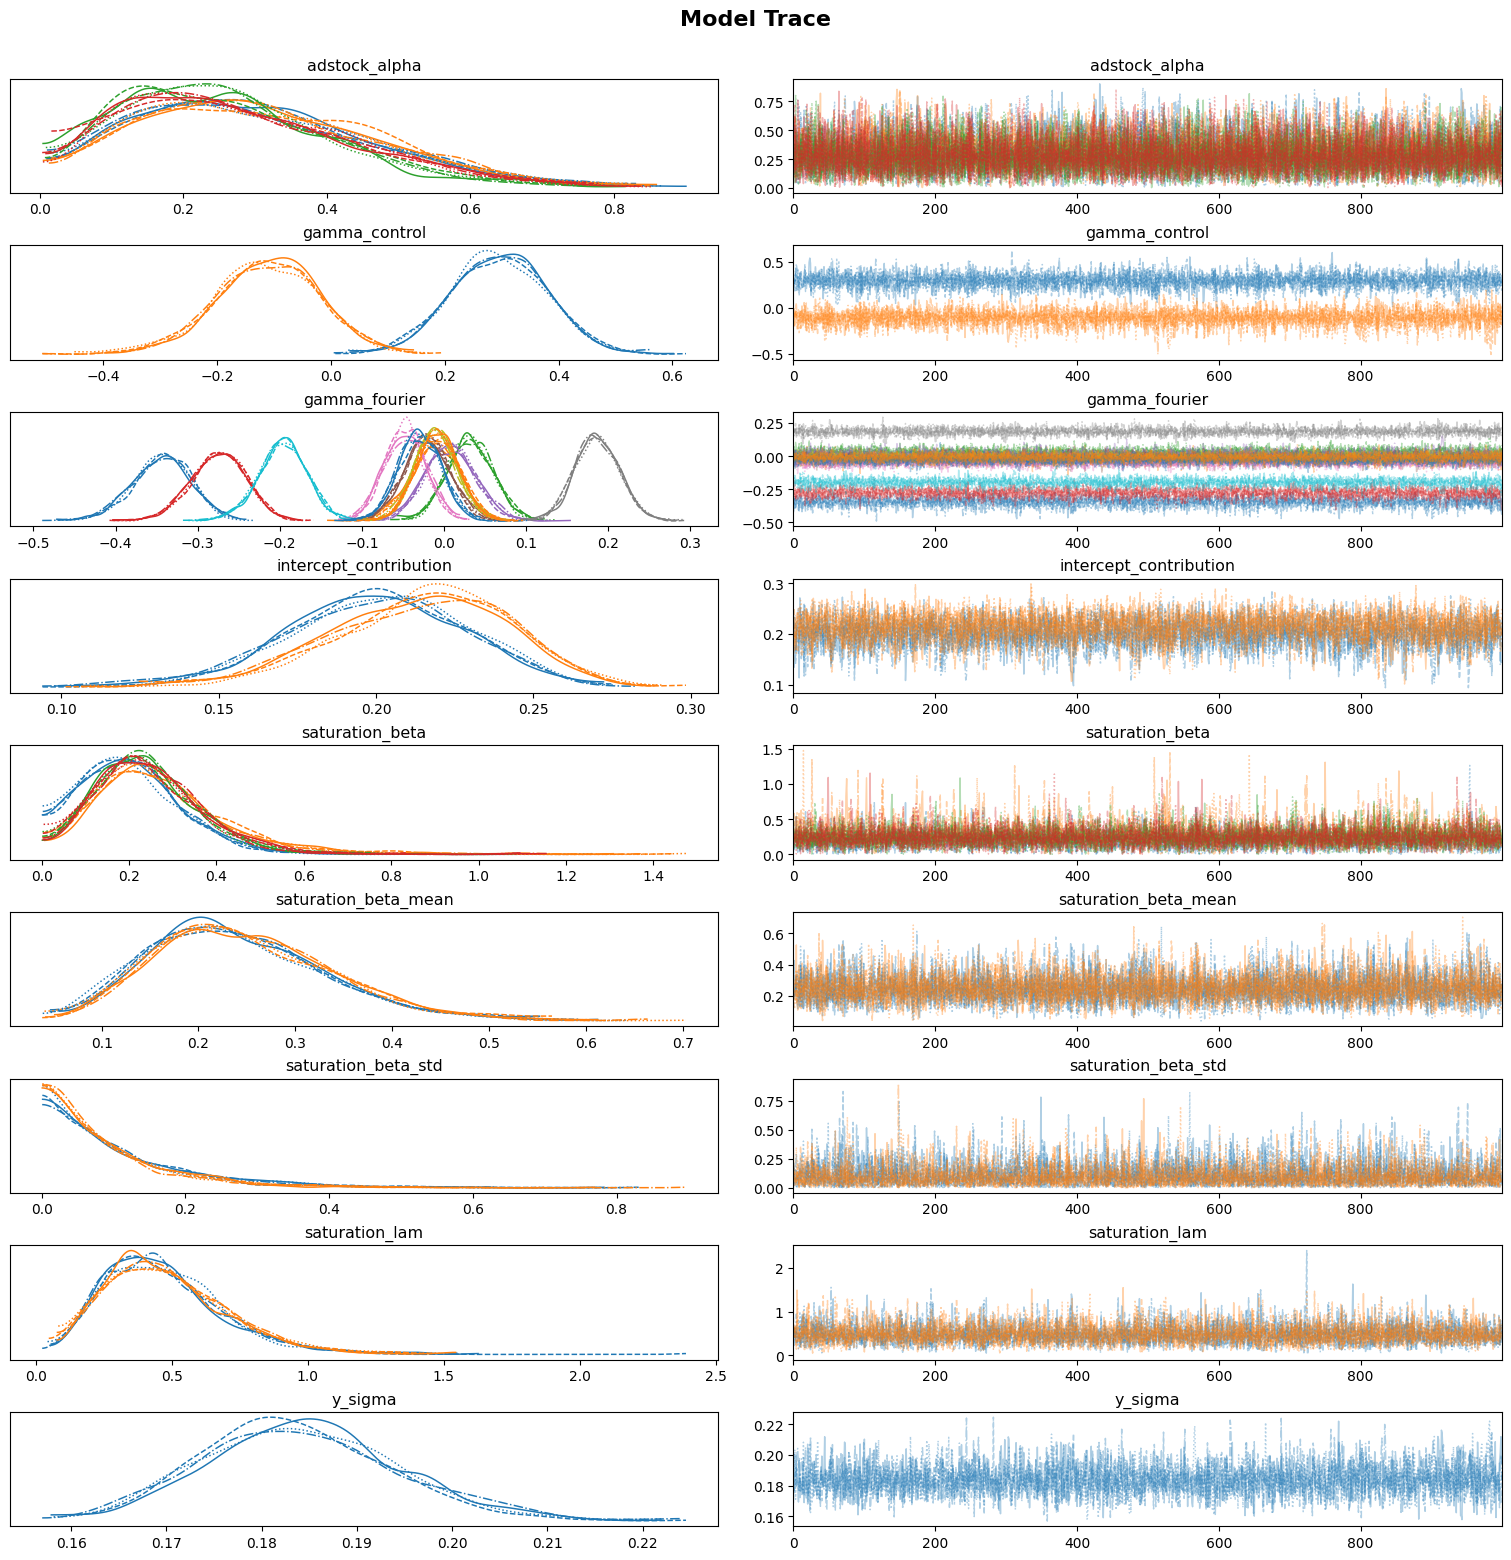

In [26]:
_ = az.plot_trace(
    data=mmm.idata,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_beta_mean",
        "saturation_beta_std",
        "saturation_lam",
        "y_sigma",
    ],
    compact=True,
    backend_kwargs={"figsize": (15, 15), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16, fontweight="bold", y=1.03)

Text(0.5, 1.03, 'Posterior Predictive')

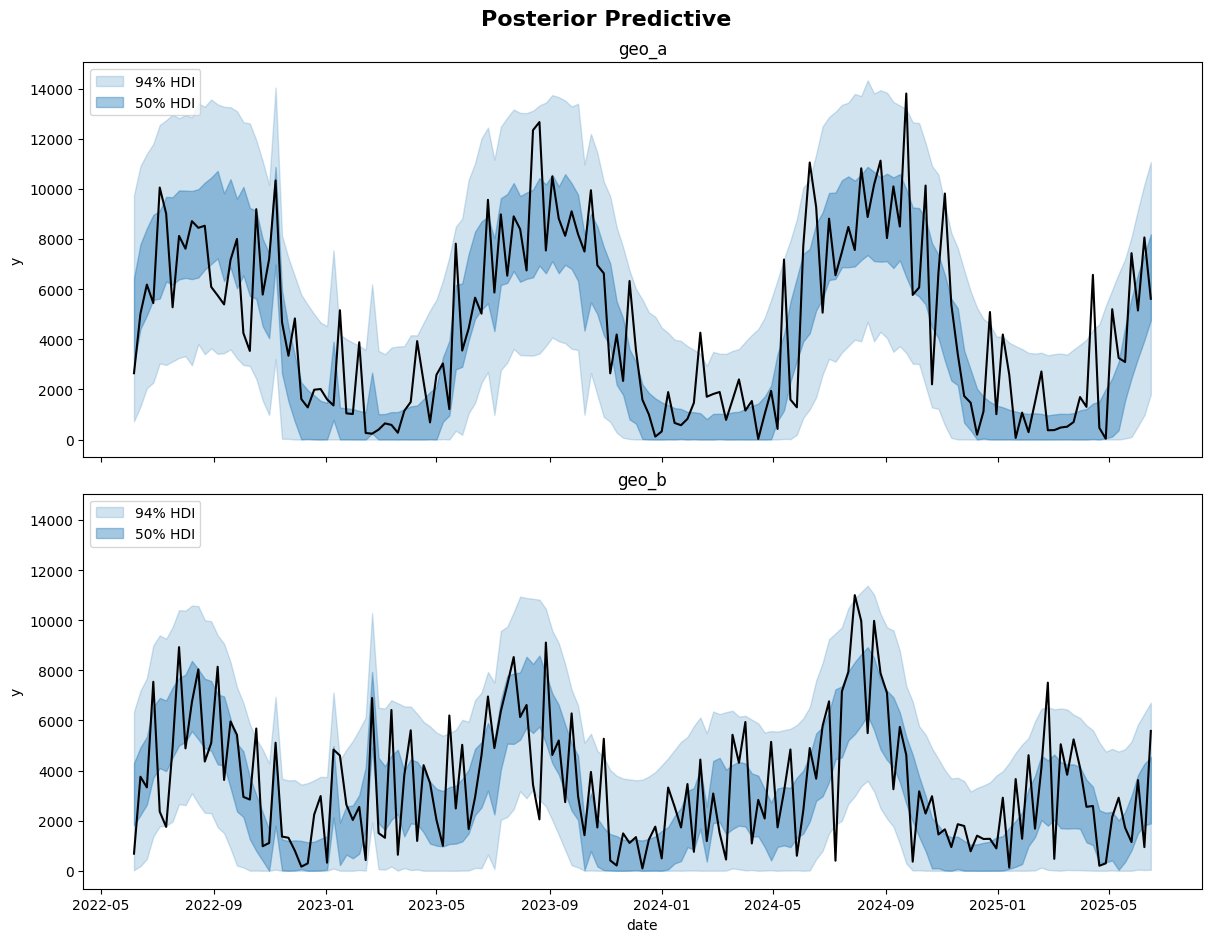

In [28]:
fig, axes = plt.subplots(
    nrows=len(mmm.model.coords["geo"]),
    figsize=(12, 9),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for i, geo in enumerate(mmm.model.coords["geo"]):
    ax = axes[i]
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=(mmm.idata["posterior_predictive"].y_original_scale.sel(geo=geo)),
        color="C0",
        smooth=False,
        hdi_prob=0.94,
        fill_kwargs={"alpha": 0.2, "label": "94% HDI"},
        ax=ax,
    )

    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=(mmm.idata["posterior_predictive"].y_original_scale.sel(geo=geo)),
        color="C0",
        smooth=False,
        hdi_prob=0.5,
        fill_kwargs={"alpha": 0.4, "label": "50% HDI"},
        ax=ax,
    )

    sns.lineplot(
        data=df.query("geo == @geo"),
        x="date",
        y="y",
        color="black",
        ax=ax,
    )

    ax.legend(loc="upper left")
    ax.set(title=f"{geo}")

fig.suptitle("Posterior Predictive", fontsize=16, fontweight="bold", y=1.03)

In [29]:
# get summary metrics; Note we are using the loaded model here; we are also averaging the posterior
# predictive samples to get a point estimate for the predictions; this is lazy but it works for now
# Note that we ave no distributions, so the HDI values will be the same as the mean predictions;

from pymc_marketing.mmm.evaluation import compute_summary_metrics

y_pred_mean = mmm.idata.posterior_predictive.y_original_scale.mean(dim=["chain", "draw"])
y_pred_flattened = y_pred_mean.to_numpy().reshape(-1, 1)
y_true_flat = mmm.y.to_numpy()

results = compute_summary_metrics(
    y_true=y_true_flat,
    y_pred=y_pred_flattened,
    metrics_to_calculate=[
        "r_squared",
        "rmse",
        "nrmse",
        "mae",
        "nmae",
        "mape",
    ],
    hdi_prob=0.95,
)

for metric, stats in results.items():
    print(f"\n{metric.upper()}:")
    for stat, value in stats.items():
        print(f"  {stat}: {value:.4f}")


R_SQUARED:
  mean: 0.6434
  median: 0.6434
  std: 0.0000
  min: 0.6434
  max: 0.6434
  95%_hdi_lower: 0.6434
  95%_hdi_upper: 0.6434

RMSE:
  mean: 1794.1171
  median: 1794.1171
  std: 0.0000
  min: 1794.1171
  max: 1794.1171
  95%_hdi_lower: 1794.1171
  95%_hdi_upper: 1794.1171

NRMSE:
  mean: 0.1301
  median: 0.1301
  std: 0.0000
  min: 0.1301
  max: 0.1301
  95%_hdi_lower: 0.1301
  95%_hdi_upper: 0.1301

MAE:
  mean: 1403.1905
  median: 1403.1905
  std: 0.0000
  min: 1403.1905
  max: 1403.1905
  95%_hdi_lower: 1403.1905
  95%_hdi_upper: 1403.1905

NMAE:
  mean: 0.1018
  median: 0.1018
  std: 0.0000
  min: 0.1018
  max: 0.1018
  95%_hdi_lower: 0.1018
  95%_hdi_upper: 0.1018

MAPE:
  mean: 1.5818
  median: 1.5818
  std: 0.0000
  min: 1.5818
  max: 1.5818
  95%_hdi_lower: 1.5818
  95%_hdi_upper: 1.5818


In [39]:
prior


Inference data with groups:
	> prior
	> prior_predictive
	> observed_data
	> constant_data

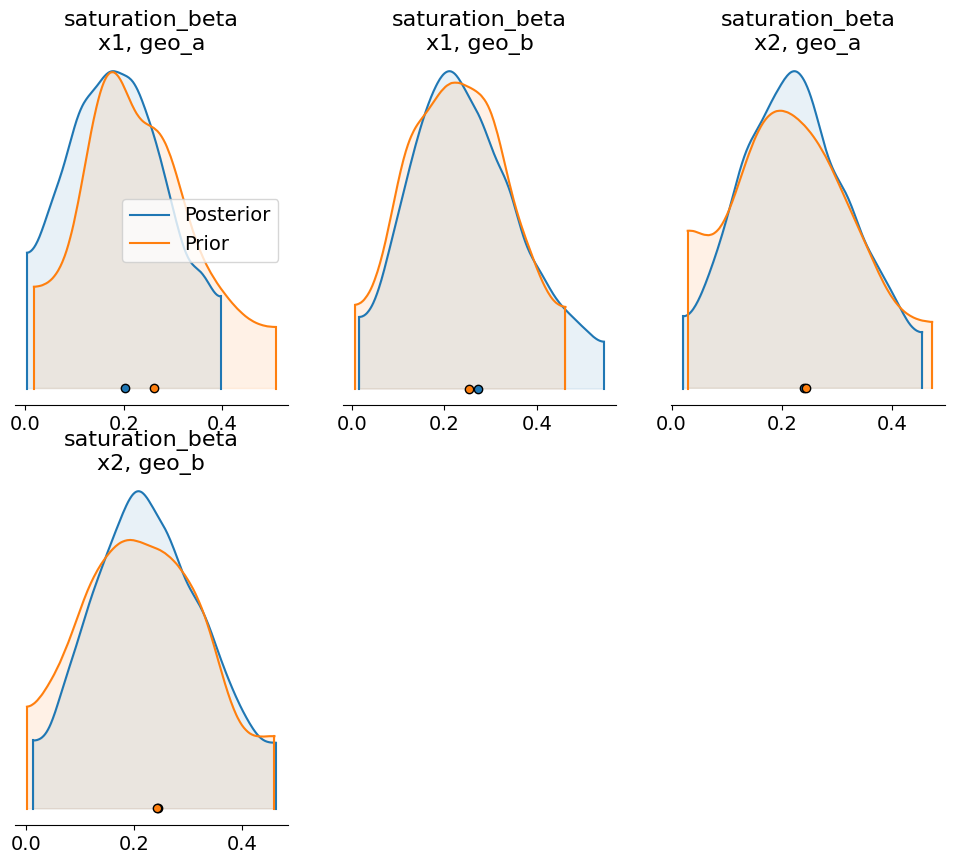

In [43]:
axes = az.plot_density(
    [mmm.idata.posterior, prior.prior],
    data_labels=["Posterior", "Prior"],
    var_names=["saturation_beta"],
    shade=0.1,
    figsize=(12, 10)
)

plt.show()

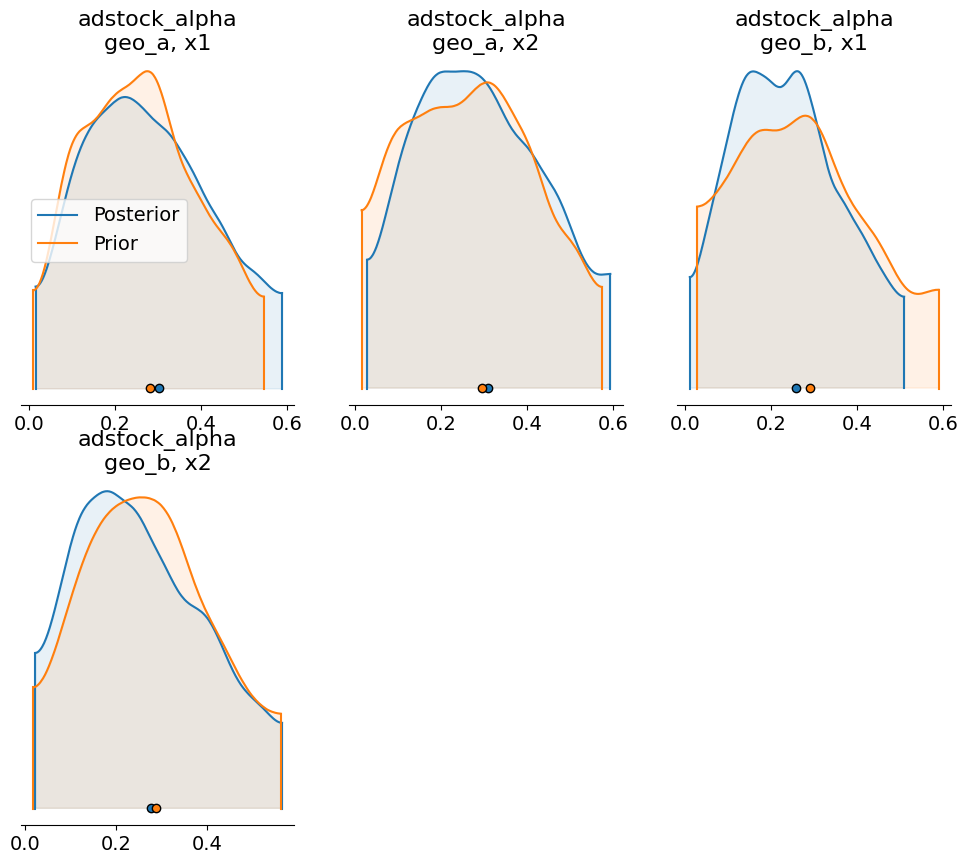

In [42]:
axes = az.plot_density(
    [mmm.idata.posterior, prior.prior],
    data_labels=["Posterior", "Prior"],
    var_names=["adstock_alpha"],
    shade=0.1,
    figsize=(12, 10)
)

plt.show()

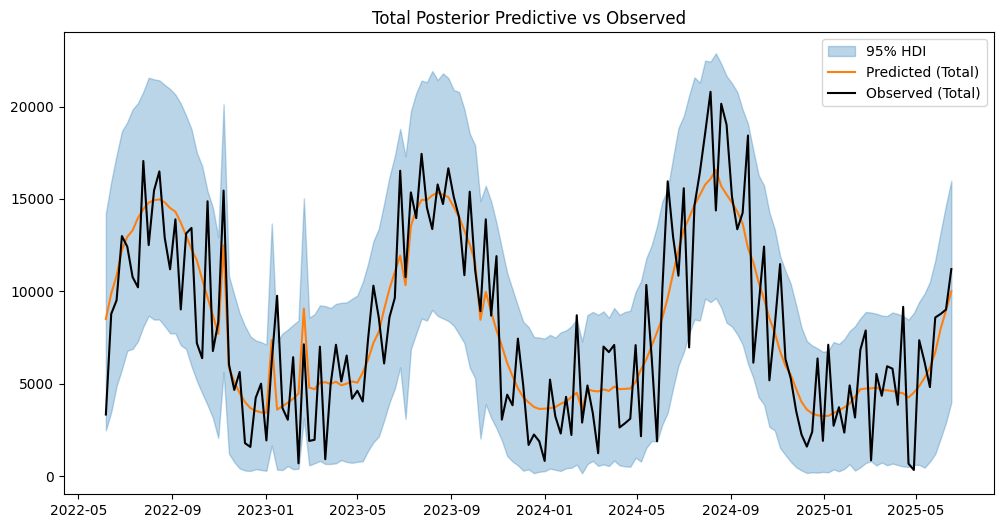

In [31]:
# posterior fit: predicted vs observed
# predictions are flattened across all geos

observed_total = df.groupby("date")["y"].sum()

post_pred_total = mmm.posterior_predictive["y_original_scale"].sum(dim="geo")

mean_prediction = post_pred_total.mean(dim=["chain", "draw"])
hdi_prediction = az.hdi(post_pred_total, hdi_prob=0.95)["y_original_scale"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(
    mean_prediction.date,
    hdi_prediction.sel(hdi="lower"),
    hdi_prediction.sel(hdi="higher"),
    alpha=0.3, color="C0", label="95% HDI"
)

ax.plot(mean_prediction.date, mean_prediction, color="C1", label="Predicted (Total)")

ax.plot(observed_total.index, observed_total.values, color="black", label="Observed (Total)")

ax.set_title("Total Posterior Predictive vs Observed")
ax.legend()
plt.show()

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'Response Decomposition Waterfall by Components'}, xlabel='Cumulative Contribution', ylabel='Components'>)

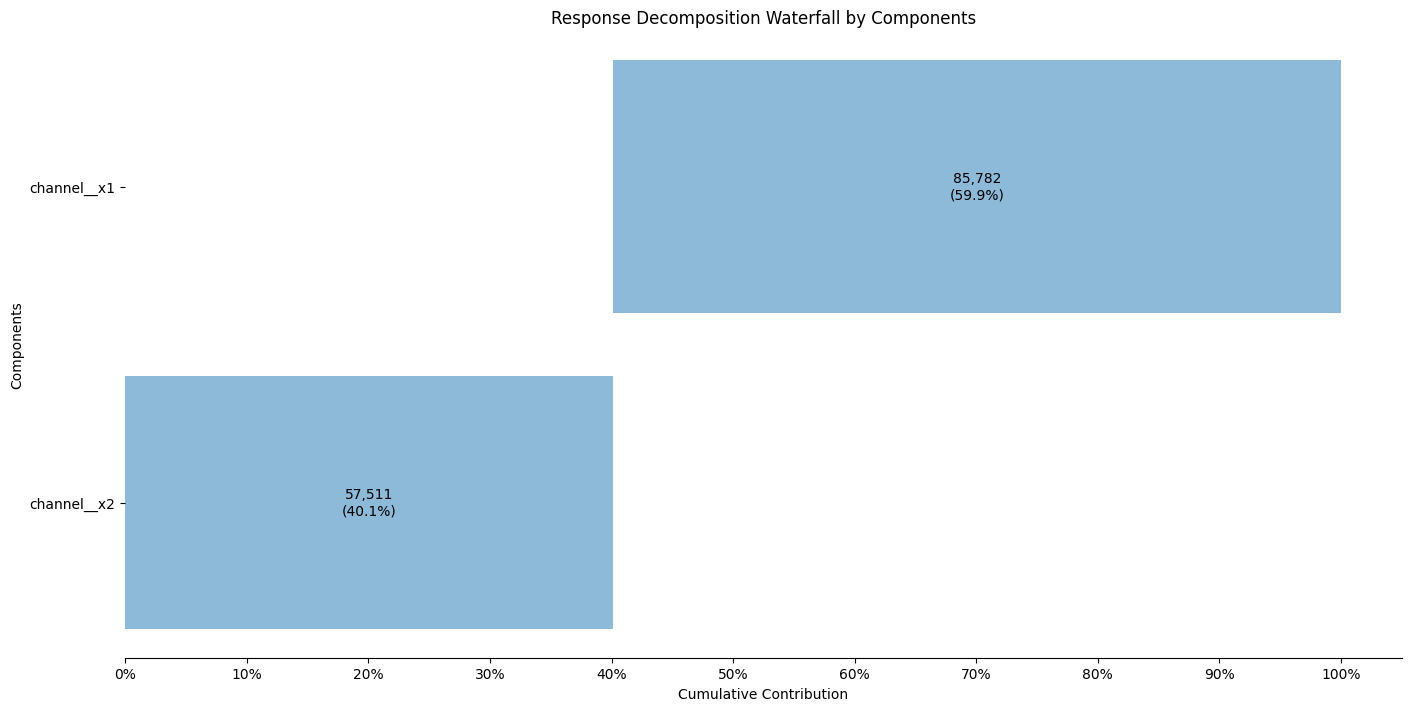

In [44]:
mmm.plot.waterfall_components_decomposition(var=["channel_contribution_original_scale"])

(<Figure size 1600x800 with 4 Axes>,
 array([[<Axes: title={'center': 'channel=x1, geo=geo_a'}, xlabel='Channel Data (X)', ylabel='Channel Contributions (Y)'>,
         <Axes: title={'center': 'channel=x1, geo=geo_b'}, xlabel='Channel Data (X)', ylabel='Channel Contributions (Y)'>],
        [<Axes: title={'center': 'channel=x2, geo=geo_a'}, xlabel='Channel Data (X)', ylabel='Channel Contributions (Y)'>,
         <Axes: title={'center': 'channel=x2, geo=geo_b'}, xlabel='Channel Data (X)', ylabel='Channel Contributions (Y)'>]],
       dtype=object))

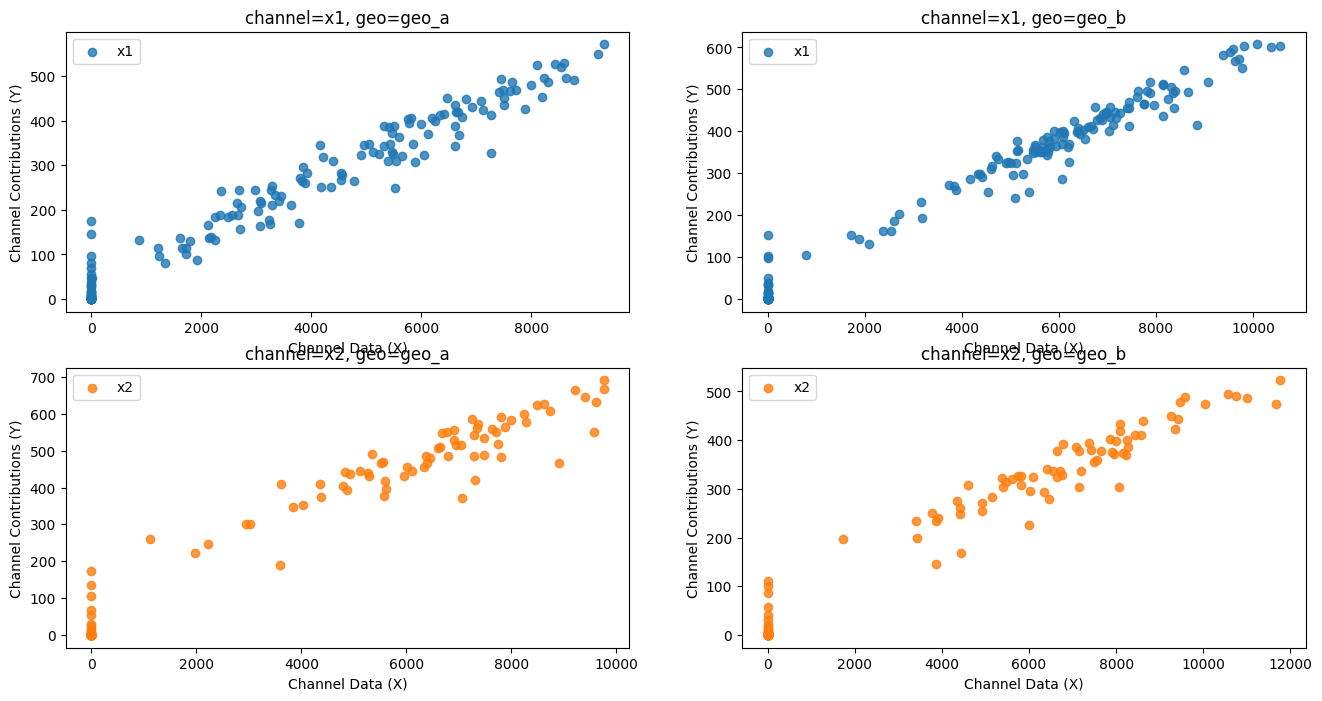

In [45]:
mmm.plot.saturation_scatterplot(width_per_col=8, height_per_row=4, original_scale=True)

Sampling: []


Output()

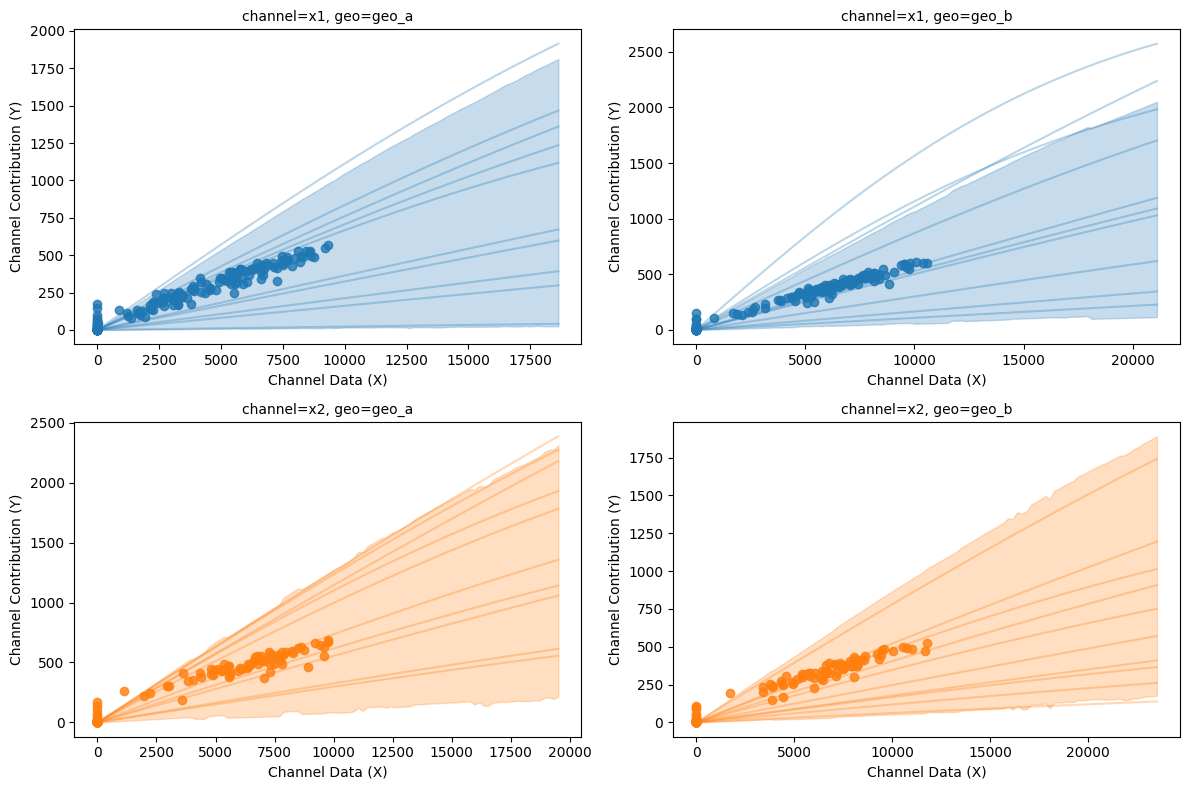

In [46]:
curve = mmm.saturation.sample_curve(mmm.idata.posterior, max_value=2)
fig, axes = mmm.plot.saturation_curves(
    curve,
    original_scale=True,
    n_samples=10,
    hdi_probs=0.85,
    random_seed=rng,
    subplot_kwargs={"figsize": (12, 8), "ncols": 2},
    rc_params={
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
    },
)

for ax in axes.ravel():
    ax.title.set_fontsize(10)

if fig._suptitle is not None:
    fig._suptitle.set_fontsize(12)

plt.tight_layout()
plt.show()

array([<Axes: title={'center': 'x\nx1'}>,
       <Axes: title={'center': 'x\nx2'}>], dtype=object)

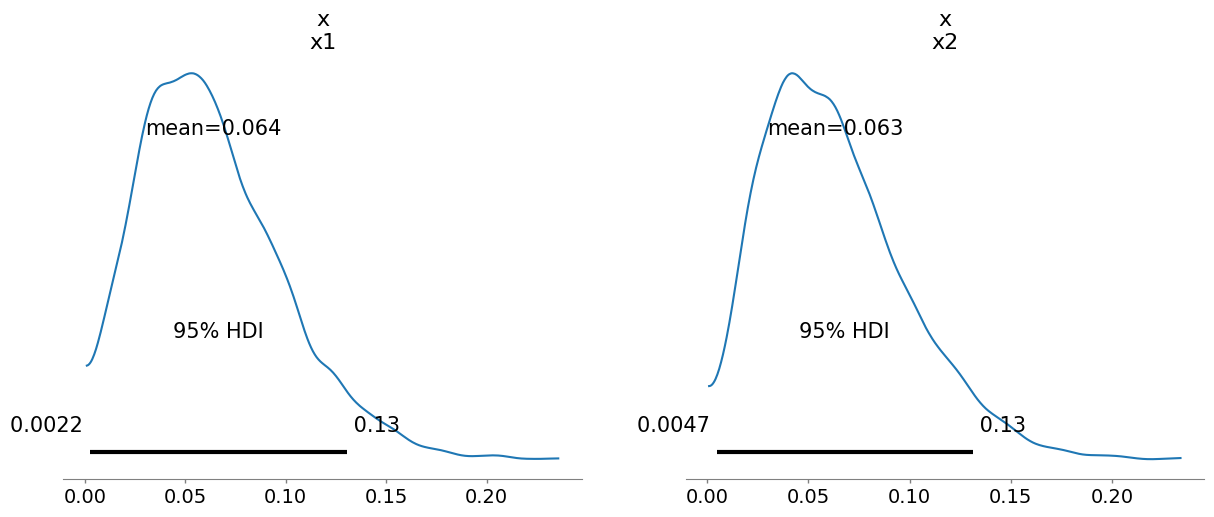

In [47]:
import xarray as xr

# Get all scales (for target and features) as an xarray Dataset
# Extract the specific scale for your target variable 'y'
y_scale = scalers["target_scale"].values

y_scale_xr = xr.DataArray(y_scale, coords={"geo": mmm.idata.posterior.geo}, dims="geo")

# Extract channel contributions and scale them to the original units
contributions_original = mmm.idata.posterior["channel_contribution"] * y_scale_xr

# sum contributions across 'date' and 'geo' to get total impact per channel
total_impact = contributions_original.sum(dim=["date", "geo"])

channel_cols = [
        'x1',
        'x2',
        ]

total_spend = x_train[channel_cols].sum().values

roas_posterior = total_impact / total_spend

az.plot_posterior(roas_posterior, hdi_prob=0.95)

# This plot shows the distribution of ROAS for each channel, allowing you to see which channels are likely to be
# more effective in driving revenue based on the model's posterior estimates. The higher the ROAS, the better the return on ad spend for that channel.

In [49]:
az.summary(roas_posterior, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x[x1],0.06400,0.03600,0.00200,0.13000,0.00100,0.00100,"3,891.00000","3,122.00000",1.00000
x[x2],0.06300,0.03500,0.00500,0.13100,0.00100,0.00100,"4,091.00000","3,102.00000",1.00000


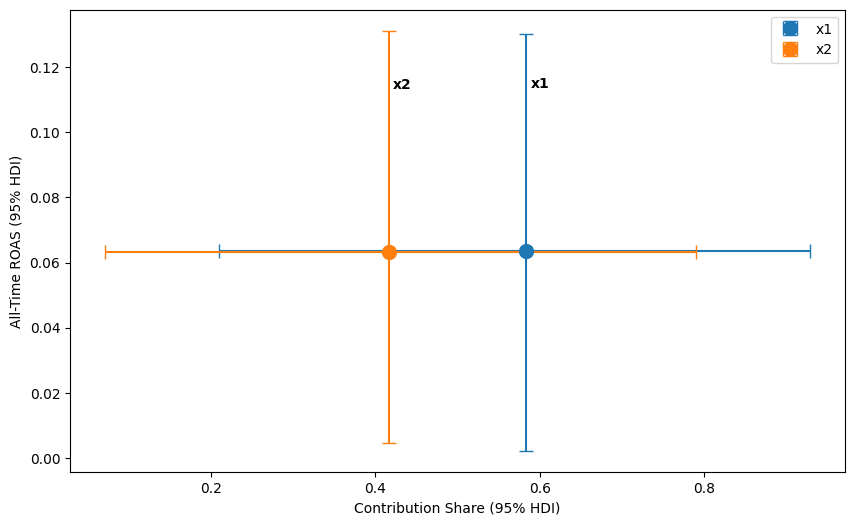

In [50]:
'''
Horizontal Bars (Share): Show how certain you are about the "volume" impact of a channel.
Vertical Bars (ROAS): Show the uncertainty in financial efficiency. Longer vertical bars often mean the channel has high variance or less data.
Strategic Overlap: If the error bars of two channels overlap significantly, the model is telling you their performance is statistically similar.

High ROAS / Low Share (Top Left): These channels are highly efficient but might be under-invested. You could likely scale these up.
Low ROAS / High Share (Bottom Right): These are your "workhorses" that drive volume but at a lower efficiency. You might be hitting saturation here.
High ROAS / High Share (Top Right): These are your "star" channels—efficient even at high volume.
Low ROAS / Low Share (Bottom Left): These channels are not currently contributing much and are inefficient.
They might be candidates for budget cuts or re-evaluation.
'''


def get_plot_stats(data_xr):
    mean = data_xr.mean(dim=["chain", "draw"]) # data_xr dims (chain, draw, channel)
    hdi = az.hdi(data_xr, hdi_prob=0.95)
    var_name = list(hdi.data_vars)[0]
    return mean, hdi[var_name]

# Sum the original scale contributions across all 4 channels to get "Total Media Impact"
total_media_impact = total_impact.sum(dim="channel")

# Calculate the share for each channel
contribution_share = total_impact / total_media_impact

roas_mean, roas_hdi = get_plot_stats(roas_posterior)
share_mean, share_hdi = get_plot_stats(contribution_share)

fig, ax = plt.subplots(figsize=(10, 6))

for i, channel in enumerate(channel_cols):
    # .isel(channel=i) grabs the specific channel's values by position
    m_x = share_mean.isel(channel=i).values
    m_y = roas_mean.isel(channel=i).values

    # Calculate error distances
    x_err = [[m_x - share_hdi.isel(channel=i, hdi=0).values],
             [share_hdi.isel(channel=i, hdi=1).values - m_x]]

    y_err = [[m_y - roas_hdi.isel(channel=i, hdi=0).values],
             [roas_hdi.isel(channel=i, hdi=1).values - m_y]]

    ax.errorbar(
        m_x, m_y,
        xerr=x_err, yerr=y_err,
        fmt='o', markersize=10, capsize=5, label=channel
    )

    ax.text(m_x + 0.005, m_y + 0.05, channel, fontweight='bold')

ax.set_xlabel("Contribution Share (95% HDI)")
ax.set_ylabel("All-Time ROAS (95% HDI)")
ax.legend()
plt.show()
